In [1]:
import datasets
dset_name = "EleutherAI/hendrycks_math"

config_names = datasets.get_dataset_config_names(dset_name)
print(config_names)

['algebra', 'counting_and_probability', 'geometry', 'intermediate_algebra', 'number_theory', 'prealgebra', 'precalculus']


In [2]:

# Load one config to inspect columns and data structure
from datasets import load_dataset, concatenate_datasets

sample = load_dataset("EleutherAI/hendrycks_math", "algebra", split="test")
print("Columns:", sample.column_names)
print("Num examples (algebra/test):", len(sample))
print("\nFirst example:")
for k, v in sample[0].items():
    print(f"  {k}: {repr(v[:200]) if isinstance(v, str) else repr(v)}")


Columns: ['problem', 'level', 'type', 'solution']
Num examples (algebra/test): 1187

First example:
  problem: 'How many vertical asymptotes does the graph of $y=\\frac{2}{x^2+x-6}$ have?'
  level: 'Level 3'
  type: 'Algebra'
  solution: 'The denominator of the rational function factors into $x^2+x-6=(x-2)(x+3)$. Since the numerator is always nonzero, there is a vertical asymptote whenever the denominator is $0$, which occurs for $x = '


In [3]:

# Check level values and distribution within a single config
from collections import Counter

print("Level values (algebra/test):")
level_counts = Counter(sample["level"])
for level, count in sorted(level_counts.items()):
    print(f"  {level}: {count}")


Level values (algebra/test):
  Level 1: 135
  Level 2: 201
  Level 3: 261
  Level 4: 283
  Level 5: 307


In [4]:

# Load all 7 configs (test split) and concatenate
all_configs = ['algebra', 'counting_and_probability', 'geometry', 
               'intermediate_algebra', 'number_theory', 'prealgebra', 'precalculus']

all_splits = [load_dataset("EleutherAI/hendrycks_math", cfg, split="test") for cfg in all_configs]
full_dataset = concatenate_datasets(all_splits)
print(f"Total examples across all configs: {len(full_dataset)}")

# Level distribution across all configs
all_levels = Counter(full_dataset["level"])
print("\nLevel distribution (all configs combined):")
total = len(full_dataset)
for level, count in sorted(all_levels.items()):
    print(f"  {level}: {count} ({100*count/total:.1f}%)")


Total examples across all configs: 5000

Level distribution (all configs combined):
  Level 1: 437 (8.7%)
  Level 2: 894 (17.9%)
  Level 3: 1131 (22.6%)
  Level 4: 1214 (24.3%)
  Level 5: 1324 (26.5%)


In [5]:

# Filter to level >= 3 (levels are strings like "Level 1", "Level 5")
filtered = full_dataset.filter(lambda x: int(x["level"].split()[-1]) >= 3)
print(f"Examples with level >= 3: {len(filtered)}")

filtered_levels = Counter(filtered["level"])
print("\nFiltered level distribution:")
for level, count in sorted(filtered_levels.items()):
    print(f"  {level}: {count}")

# Also check the 'type' column (math category, distinct from dataset type)
print("\nMath category ('type') distribution (sample):")
type_counts = Counter(filtered["type"])
for t, count in sorted(type_counts.items(), key=lambda x: -x[1]):
    print(f"  {t}: {count}")


Filter:   0%|          | 0/5000 [00:00<?, ? examples/s]

Examples with level >= 3: 3669

Filtered level distribution:
  Level 3: 1131
  Level 4: 1214
  Level 5: 1324

Math category ('type') distribution (sample):
  Algebra: 851
  Intermediate Algebra: 723
  Prealgebra: 608
  Number Theory: 418
  Precalculus: 376
  Geometry: 359
  Counting & Probability: 334


## Analysis of DeepSeek-Llama-8B on MATH_open

In [6]:
import json
import os
import re
from dotenv import load_dotenv

load_dotenv()

with open("data/collection/deepseek_llama_8b/math_open.json") as f:
    data = json.load(f)

print(f"Loaded {len(data)} records")
print(f"Fields: {[k for k, v in data[0].items() if not isinstance(v, list) or len(v) <= 20]}")
print(f"Paths per prompt: {len(data[0]['all_sampled_answers'])}")


Loaded 100 records
Fields: ['base_answer_rate', 'base_answer_cut_short', 'num_random_cut_short', 'alternate_answers', 'alternate_finish_reasons', 'base_answer_type', 'all_sampled_answers', 'raw_answer', 'clean_answer', 'prompt_id', 'rollout_id', 'output_text', 'finish_reason', 'question', 'question_with_choices', 'correct_letter', 'correct_answer', 'all_letters', 'all_answers', 'dataset_name', 'dataset_type', 'prompt', 'base', 'alternate_texts']
Paths per prompt: 16


In [16]:
data[0]["correct_answer"]

'Let the first term be $a$ and the common difference be $d$.  The sum of an arithmetic series is equal to the average of the first and last term, multiplied by the number of terms.  The fifth term is $a + 4d$, so the sum of the first five terms is \\[\\frac{a + (a + 4d)}{2} \\cdot 5 = 5a + 10d = 70,\\]which implies that $a + 2d = 14$, so $2d = 14 - a$.\n\nThe tenth term is $a + 9d$, so the sum of the first ten terms is \\[\\frac{a + (a + 9d)}{2} \\cdot 10 = 10a + 45d = 210,\\]which implies that $2a + 9d = 42$, so $9d = 42 - 2a$.\n\nFrom the equation $2d = 14 - a$, $18d = 126 - 9a$, and from the equation $9d = 42 - 2a$, $18d = 84 - 4a$, so \\[126 - 9a = 84 - 4a.\\]Then $5a = 42$, so $a = \\boxed{\\frac{42}{5}}$.'

In [7]:
def extract_boxed(text: str) -> str | None:
    """Extract the content of the last \\boxed{...} in a string, handling nested braces."""
    result = None
    for m in re.finditer(r'\\boxed\{', text):
        start = m.end()
        depth, i = 1, start
        while i < len(text) and depth > 0:
            if text[i] == '{':
                depth += 1
            elif text[i] == '}':
                depth -= 1
            i += 1
        if depth == 0:
            result = text[start:i - 1]
    return result

# Verify on a few records
for r in data[:3]:
    gt = extract_boxed(r['correct_answer'])
    print(f"prompt_id={r['prompt_id']}  boxed_gt={repr(gt)}  model_base={repr(r['clean_answer'])}")


prompt_id=9  boxed_gt='\\frac{42}{5}'  model_base='8.'
prompt_id=28  boxed_gt='31'  model_base='20.'
prompt_id=38  boxed_gt='-\\frac{49}{12}'  model_base='-\\frac'


In [8]:
from openai import OpenAI
from concurrent.futures import ThreadPoolExecutor, as_completed

OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY")
assert OPENROUTER_API_KEY, "OPENROUTER_API_KEY not found in .env"

client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=OPENROUTER_API_KEY,
)

JUDGE_MODEL = "meta-llama/llama-3.2-3b-instruct"

JUDGE_PROMPT = """\
You are a math answer checker. Given a math problem, the correct answer, and a model's answer, \
determine if the model's answer is mathematically equivalent to the correct answer. \
Equivalent means the same value even if written differently (e.g. 42/5 = 8.4, \\frac{{1}}{{2}} = 0.5).

Problem:
{question}

Correct answer: {ground_truth}

Model's answer: {model_answer}

Is the model's answer correct? Reply with only YES or NO."""


def judge_answer(question: str, ground_truth: str, model_answer: str) -> bool:
    resp = client.chat.completions.create(
        model=JUDGE_MODEL,
        messages=[{"role": "user", "content": JUDGE_PROMPT.format(
            question=question, ground_truth=ground_truth, model_answer=model_answer
        )}],
        max_tokens=5,
        temperature=0,
    )
    return resp.choices[0].message.content.strip().upper().startswith("YES")

# Quick sanity check
print(judge_answer("What is 2+2?", "4", "4"))
print(judge_answer("What is 2+2?", "4", "5"))


True
False


In [ ]:
from tqdm.notebook import tqdm

def judge_record(record):
    """Judge all unique answers for a record, return per-record accuracy stats."""
    question = record["question"]
    gt_boxed = extract_boxed(record["correct_answer"]) or record["correct_answer"]
    all_answers = record["all_sampled_answers"]

    # Judge each unique answer once to minimise API calls
    unique_answers = list(set(all_answers))
    verdicts = {}
    for ans in unique_answers:
        verdicts[ans] = judge_answer(question, gt_boxed, ans)

    num_correct = sum(verdicts[ans] for ans in all_answers)
    return {
        "prompt_id": record["prompt_id"],
        "question": record["question"][:120].replace("\n", " "),
        "ground_truth": gt_boxed,
        "base_answer": record["clean_answer"],
        "base_correct": verdicts[record["clean_answer"]],
        "num_correct": num_correct,
        "num_paths": len(all_answers),
        "accuracy": num_correct / len(all_answers),
        "base_answer_rate": record["base_answer_rate"],  # agreement among alternates
        "num_cut_short": record["num_random_cut_short"],
        "all_answers": all_answers,
        "verdicts": [verdicts[ans] for ans in all_answers],
    }

# Run in parallel (ThreadPoolExecutor is safe in notebooks)
judge_results = [None] * len(data)
with ThreadPoolExecutor(max_workers=16) as pool:
    futures = {pool.submit(judge_record, record): i for i, record in enumerate(data)}
    for future in tqdm(as_completed(futures), total=len(data), desc="Judging"):
        i = futures[future]
        judge_results[i] = future.result()

print("Done.")


Judging:   0%|          | 0/100 [00:00<?, ?it/s]

Done.


In [10]:
import pandas as pd

pd.set_option("display.max_colwidth", 80)
pd.set_option("display.float_format", "{:.2%}".format)

df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ("all_answers", "verdicts")}
    for r in judge_results
]).sort_values("prompt_id").reset_index(drop=True)

print(f"Base answer accuracy  (greedy):  {df['base_correct'].mean():.2%}")
print(f"Mean accuracy over {df['num_paths'].iloc[0]} paths:  {df['accuracy'].mean():.2%}")
print(f"pass@1 (base):                   {df['base_correct'].mean():.2%}")
print()
df[["prompt_id", "question", "ground_truth", "base_answer", "base_correct", "num_correct", "num_paths", "accuracy"]]


Base answer accuracy  (greedy):  62.00%
Mean accuracy over 16 paths:  58.56%
pass@1 (base):                   62.00%



,prompt_id,question,ground_truth,base_answer,base_correct,num_correct,num_paths,accuracy
0,0,Let $ABCDEFG$ be a regular heptagon with center $O$. Let $M$ be the centroi...,\frac{1}{8},1/,False,0,16,0.00%
1,1,"In a group of 30 high school students, 8 take French, 12 take Spanish and 3 ...",13,13,True,16,16,100.00%
2,2,A rotation centered at the origin takes $\begin{pmatrix} 13 \\ 0 \end{pmatri...,\begin{pmatrix} 12/13 \\ 5/13 \end{pmatrix},[\d,False,0,16,0.00%
3,3,Express $\dfrac{6}{\sqrt{245}+3\sqrt{125}+4\sqrt{45}}$ in the form $\frac{A\...,93,93,True,16,16,100.00%
4,4,Suppose $r$ is a real number for which \[\left\lfloor r + \frac{19}{100} \ri...,743,743,True,10,16,62.50%
...,...,...,...,...,...,...,...,...
95,95,Find an integer $n$ such that $0\leq n<398$ and $n$ is a multiplicative inve...,57,57,True,16,16,100.00%
96,96,"$20!$ has 19 digits, the last 18 of which are 432902008176640000. What is th...",2,2,True,16,16,100.00%
97,97,Compute \[\tan 20^\circ + \tan 40^\circ + \sqrt{3} \tan 20^\circ \tan 40^\ci...,\sqrt{3},sqrt(,False,1,16,6.25%
98,98,"Let $a$, $b$, and $c$ be three distinct one-digit numbers. What is the maxim...",\frac{33}{2},16.,False,0,16,0.00%


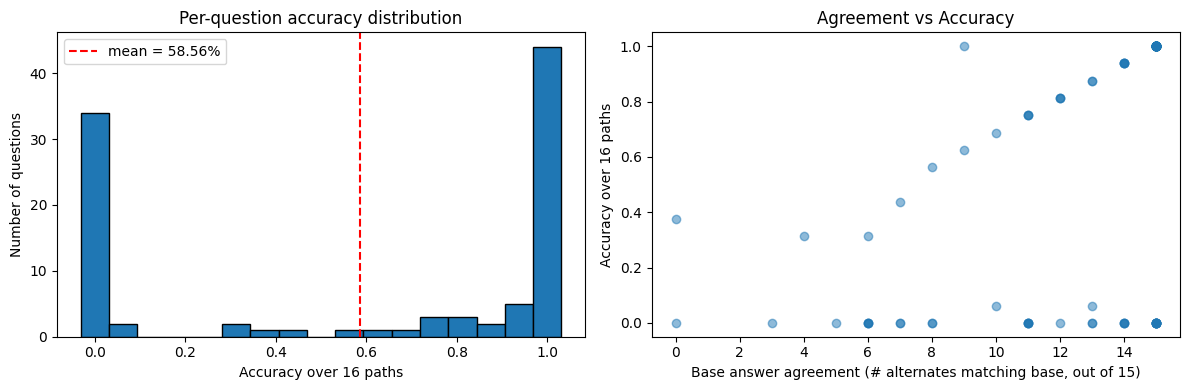

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["accuracy"], bins=17, range=(-1/32, 1 + 1/32), edgecolor="black")
axes[0].set_xlabel("Accuracy over 16 paths")
axes[0].set_ylabel("Number of questions")
axes[0].set_title("Per-question accuracy distribution")
axes[0].axvline(df["accuracy"].mean(), color="red", linestyle="--", label=f"mean = {df['accuracy'].mean():.2%}")
axes[0].legend()

# Accuracy vs answer agreement (base_answer_rate = how many alternates agree with base)
axes[1].scatter(df["base_answer_rate"], df["accuracy"], alpha=0.5)
axes[1].set_xlabel("Base answer agreement (# alternates matching base, out of 15)")
axes[1].set_ylabel("Accuracy over 16 paths")
axes[1].set_title("Agreement vs Accuracy")

plt.tight_layout()
plt.show()


In [14]:
df[(df['accuracy'] < 0.75) & (df['accuracy'] > 0.25)]

,prompt_id,question,ground_truth,base_answer,base_correct,num_correct,num_paths,accuracy,base_answer_rate,num_cut_short
4,4,Suppose $r$ is a real number for which \[\left\lfloor r + \frac{19}{100} \ri...,743,743,True,10,16,62.50%,9,0
22,22,"Two circles of radius 1 are centered at $(4,0)$ and $(-4,0).$ How many circl...",4,2,False,5,16,31.25%,6,9
28,28,"As shown, a square is constructed on the hypotenuse of a right triangle whos...",31,20.,False,7,16,43.75%,7,0
55,55,"If $2x+3y = 4$ and $y = 34$, what is the value of $x$?",-49,-49,True,11,16,68.75%,10,0
70,70,"In convex hexagon $ABCDEF$, all six sides are congruent, $\angle A$ and $\an...",46,46,True,9,16,56.25%,8,7
75,75,"Determine the smallest positive value of $x,$ in degrees, for which \[\tan (...",30^\circ,30°,True,6,16,37.50%,0,14
89,89,How many ways are there for 8 people to sit around a circular table if none ...,1440,1440,True,5,16,31.25%,4,10


In [20]:
print(df.iloc[4]["question"])

Suppose $r$ is a real number for which \[\left\lfloor r + \frac{19}{100} \right\rfloor + \left\lfloor r + \frac{20}{100}
